In [1]:

import numpy as np
from sklearn import datasets

from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import metrics

from sklearn import decomposition
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.feature_selection import RFE


downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\mymai\scikit_learn_data
(400, 4096)
(400, 64, 64)


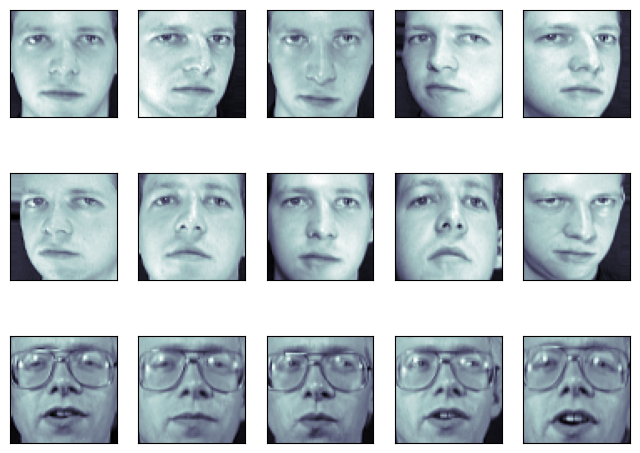

In [2]:
## LOAD DATA
faces = datasets.fetch_olivetti_faces()
print(faces.data.shape)
print(faces.images.shape)

## PLOT DATA SAMPLES
fig = plt.figure(figsize=(8, 6))
# plot several images
for i in range(15):
    ax = plt.subplot(3, 5, i + 1, xticks=[], yticks=[])
    ax.imshow(faces.images[i], cmap=plt.cm.bone)

In [3]:
## SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(faces.data, faces.target, random_state=0)

d:\workspace\MachineLearning\venv\lib\site-packages\sklearn\linear_model\_logistic.py:1183: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(


Accuracy: 0.60


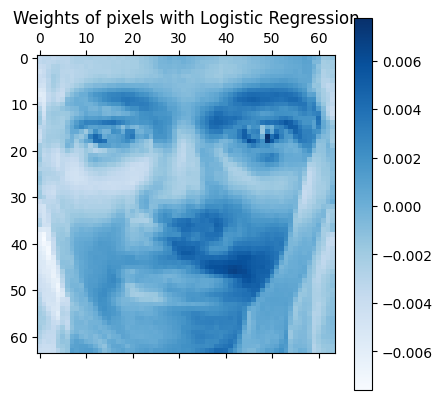

In [4]:
## LOGISTIC REGRESSION ON ALL PIXELS
log_reg=LogisticRegression(penalty='none',solver='saga', tol=0.1, multi_class='multinomial')

log_reg.fit(X_train, y_train)

class_est = log_reg.predict(X_test)

acc=np.sum(class_est==y_test)/y_test.shape[0]

print('Accuracy: %0.2f' % acc)

# Plot weights
weights = log_reg.coef_[0].reshape(faces.images[0].shape)
plt.matshow(weights, cmap=plt.cm.Blues)
plt.colorbar()
plt.title("Weights of pixels with Logistic Regression")
plt.show()

Accuracy: 0.61
Number of coefficients eliminated 0
Percentage of coefficients eliminated 0.0000


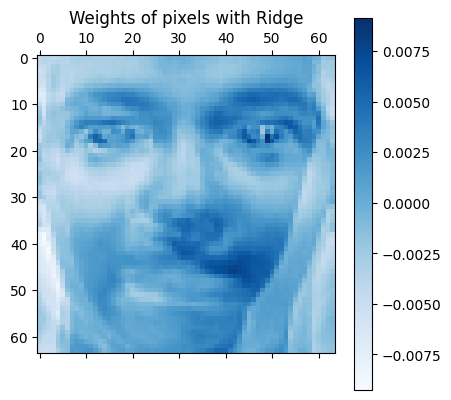

In [5]:
## RIDGE REGRESSION

log_reg=LogisticRegression(penalty='l2', C=1, solver='saga', tol=0.1, multi_class='multinomial')

log_reg.fit(X_train, y_train)

class_est = log_reg.predict(X_test)

acc=np.sum(class_est==y_test)/y_test.shape[0]
print('Accuracy: %0.2f' % acc)
print('Number of coefficients eliminated %d' % np.sum(log_reg.coef_[0]==0))
print('Percentage of coefficients eliminated %.4f' % (np.sum(log_reg.coef_[0]==0)/(64*64)))

weights = log_reg.coef_[0].reshape(faces.images[0].shape)
plt.matshow(weights, cmap=plt.cm.Blues)
plt.colorbar()
plt.title("Weights of pixels with Ridge")
plt.show()

Accuracy: 0.46
Number of coefficients eliminated 2194
Percentage of coefficients eliminated 0.5356


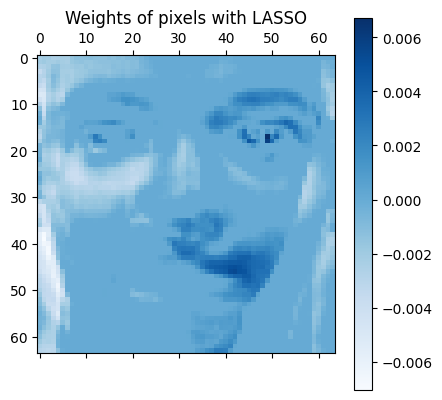

In [6]:
## LASSO REGRESSION
log_reg=LogisticRegression(penalty='l1', C=3, solver='saga', tol=0.1, multi_class='multinomial')

log_reg.fit(X_train, y_train)

class_est = log_reg.predict(X_test)

acc=np.sum(class_est==y_test)/y_test.shape[0]
print('Accuracy: %0.2f' % acc)
print('Number of coefficients eliminated %d' % np.sum(log_reg.coef_[0]==0))
print('Percentage of coefficients eliminated %.4f' % (np.sum(log_reg.coef_[0]==0)/(64*64)))

weights = log_reg.coef_[0].reshape(faces.images[0].shape)
plt.matshow(weights, cmap=plt.cm.Blues)
plt.colorbar()
plt.title("Weights of pixels with LASSO")
plt.show()

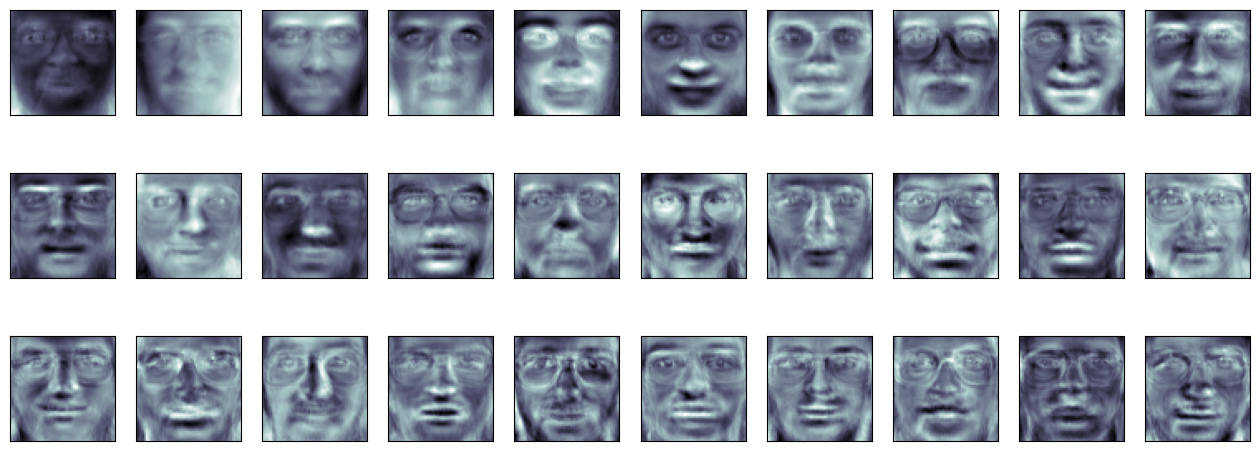

In [7]:
## PCA
## Estimating PCA transformation on the training set
# Applying the (same!) transformation to the training and test set
N_components=150
pca = decomposition.PCA(n_components=N_components, whiten=True)
pca.fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

#Plot the first eigenfaces
fig = plt.figure(figsize=(16, 6))
for i in range(30):
    ax = fig.add_subplot(3, 10, i + 1, xticks=[], yticks=[])
    ax.imshow(pca.components_[i].reshape(faces.images[0].shape),
              cmap=plt.cm.bone)
    


d:\workspace\MachineLearning\venv\lib\site-packages\sklearn\linear_model\_logistic.py:1183: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(


Accuracy of logistic regression with PCA: 0.96
Number of components 150
Percentage of coefficients eliminated 0.9634


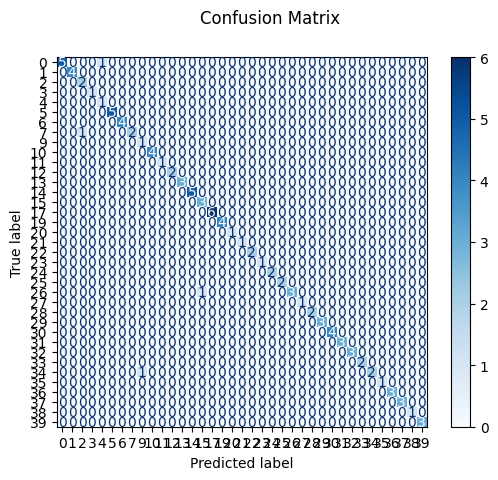

In [10]:
## Logistic regression using the PCA coding

log_reg=LogisticRegression(penalty='none', solver='saga', tol=0.1, multi_class='multinomial')

log_reg.fit(X_train_pca, y_train)

class_est = log_reg.predict(X_test_pca)

acc=np.sum(class_est==y_test)/y_test.shape[0]

print('Accuracy of logistic regression with PCA: %0.2f' % acc)
print('Number of components %d' % N_components)
print('Percentage of coefficients eliminated %.4f' % ((64*64-N_components)/(64*64)))

#print(acc)
cm = metrics.confusion_matrix(y_test, np.round(class_est))
disp = metrics.ConfusionMatrixDisplay.from_estimator(
    log_reg, X_test_pca, y_test, cmap=plt.cm.Blues
)
disp.figure_.suptitle("Confusion Matrix");

Text(0, 0.5, 'Fraction of variance explained')

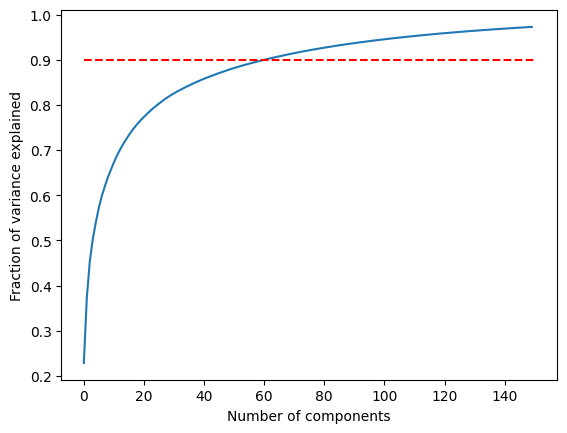

In [11]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.plot([0,N_components],[0.9,0.9],'--r')
plt.xlabel('Number of components')
plt.ylabel('Fraction of variance explained')